# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
aviation_df = pd.read_csv('cleaned_aviation_data')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
large_capacity_plane = aviation_df[aviation_df['Total.Estimated.People'] >= 20]

small_capacity_plane = aviation_df[aviation_df['Total.Estimated.People'] < 20]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

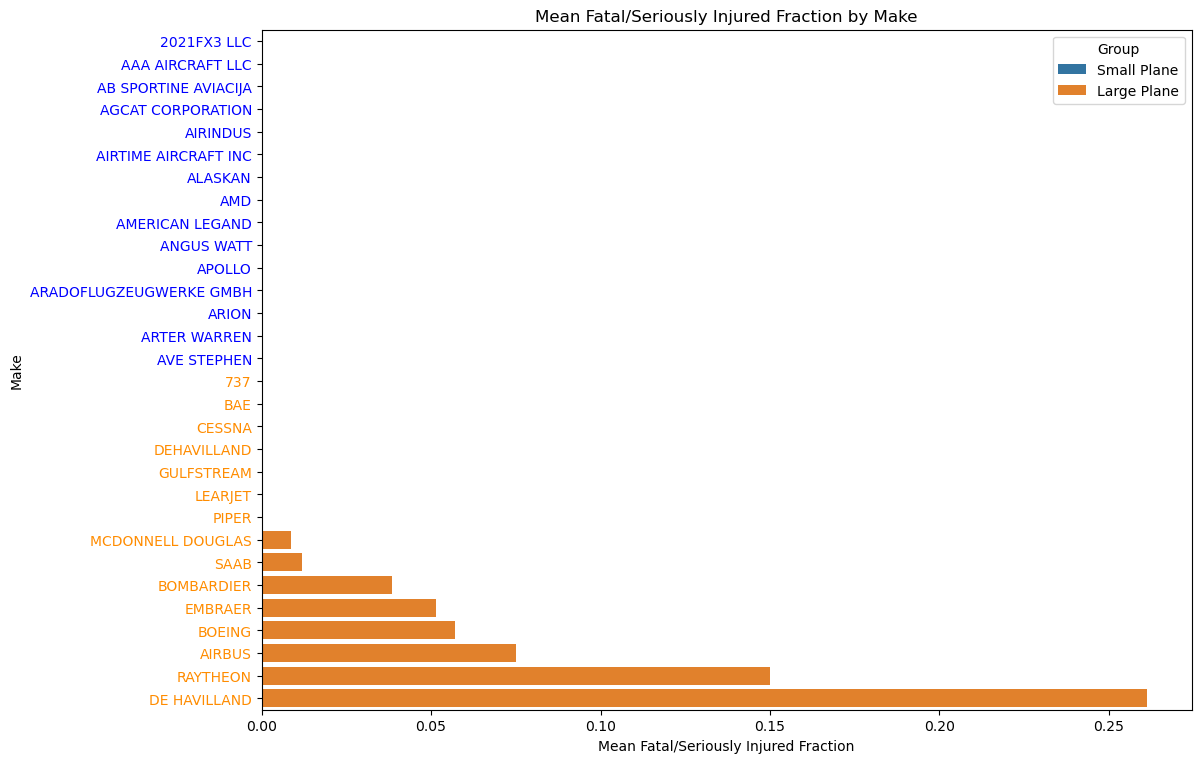

In [4]:
# Calculate mean for each Make
large_make_risk = (
    large_capacity_plane
    .dropna(subset=['Injury.Percentage'])
    .groupby('Make')['Injury.Percentage']
    .mean()
    .reset_index()
)

small_make_risk = (
    small_capacity_plane
    .dropna(subset=['Injury.Percentage'])
    .groupby('Make')['Injury.Percentage']
    .mean()
    .reset_index()
)

# Get the 15 Makes with the lowest mean
large_top15 = large_make_risk.nsmallest(15, 'Injury.Percentage')
small_top15 = small_make_risk.nsmallest(15, 'Injury.Percentage')

# Combine ONLY the top 15 from each group
plot_df = pd.concat([
    small_top15.assign(Group='Small Plane'),
    large_top15.assign(Group='Large Plane')
])

# Plot the graph
plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=plot_df,
    x='Injury.Percentage',
    y='Make',
    hue='Group'
)

plt.xlabel('Mean Fatal/Seriously Injured Fraction')
plt.ylabel('Make')
plt.title('Mean Fatal/Seriously Injured Fraction by Make')

# findings
plt.subplots_adjust(bottom=0.20)


# Color 'Make' names according to their group for clarity
for label in ax.get_yticklabels():
    make = label.get_text()
    group = plot_df.loc[plot_df['Make'] == make, 'Group'].iloc[0]
    
    if group == 'Small Plane':
        label.set_color('blue')
    else:
        label.set_color('darkorange')

plt.show()


Small and large plane text is color coded for easier readability. Based on the chart, small planes do not show significant fatal fraction rates compared to larger planes. From the data large planes with the Make DE Havilland appear to show the greatest injury/mortality rate.

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

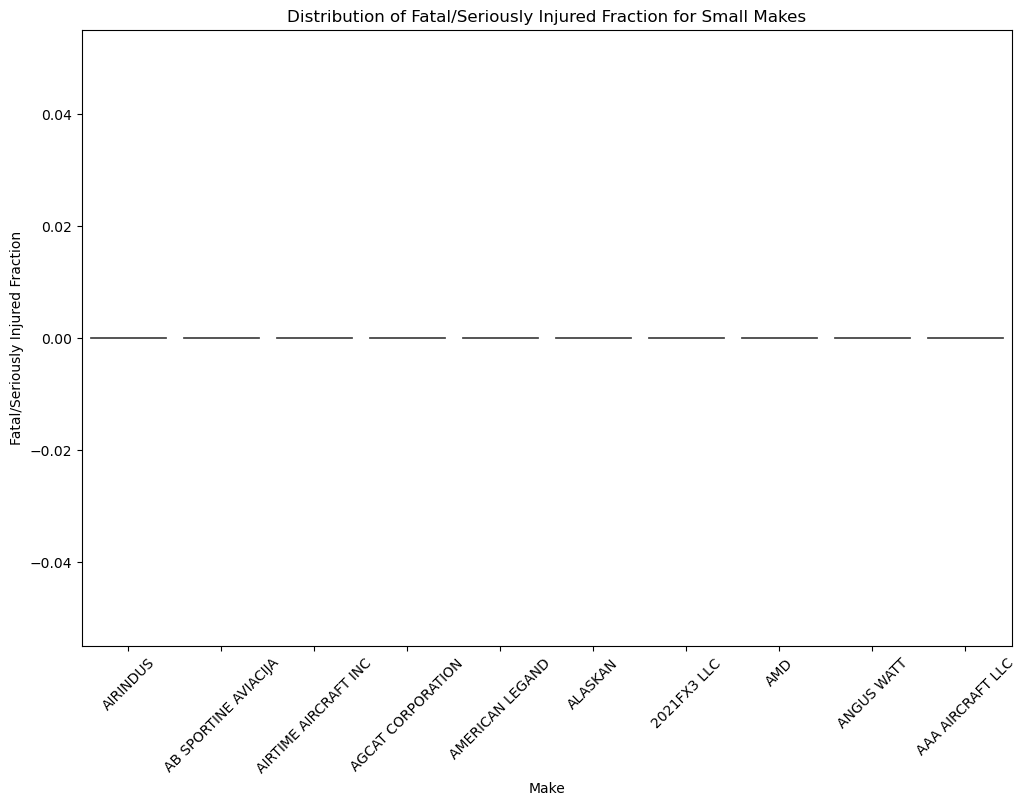

In [5]:
# Find the 10 Makes with the lowest mean injury rate
small_make_risk = (
    small_capacity_plane
    .groupby('Make')['Injury.Percentage']
    .mean()
    .reset_index()
)

small_top10 = small_make_risk.nsmallest(
    10, 'Injury.Percentage'
)

# Keep only those 10 Makes in the original data
small_top10_data = small_capacity_plane[
    small_capacity_plane['Make'].isin(small_top10['Make'])
]

plt.figure(figsize=(12, 8))

sns.violinplot(
    data=small_top10_data,
    x='Make',
    y='Injury.Percentage'
)

plt.xticks(rotation=45)
plt.xlabel('Make')
plt.ylabel('Fatal/Seriously Injured Fraction')
plt.title('Distribution of Fatal/Seriously Injured Fraction for Small Makes')

plt.show()


No findings for this data

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

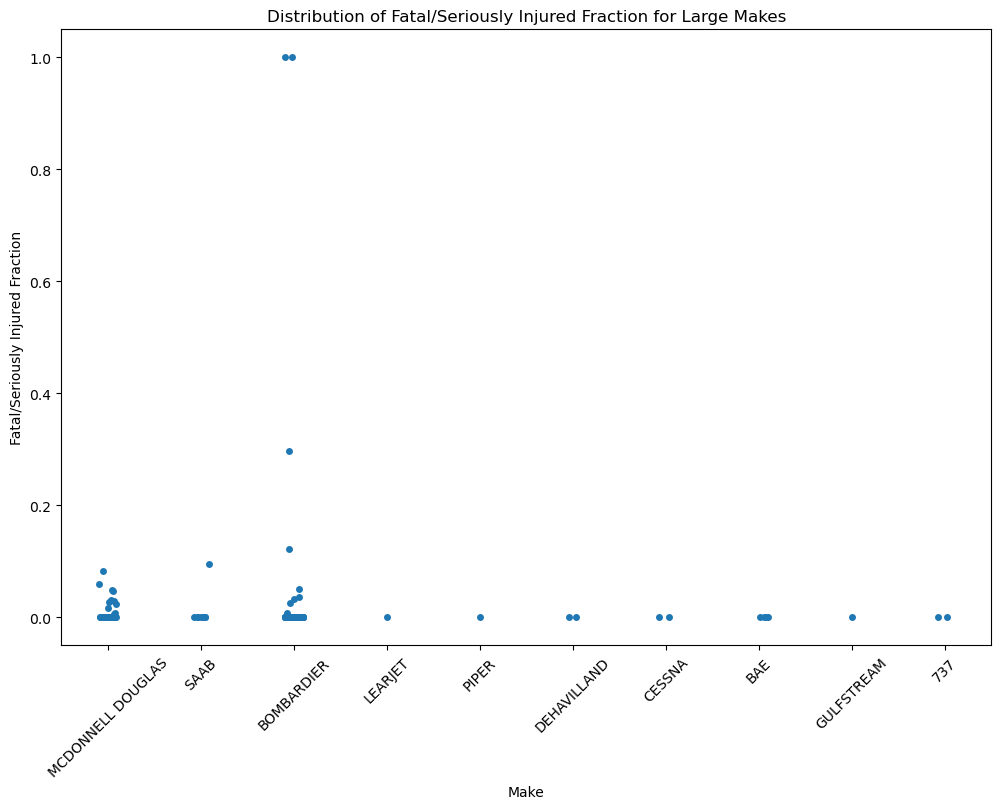

In [6]:
# Calculate the mean injury rate for each Make
large_make_risk = (
    large_capacity_plane
    .groupby('Make')['Injury.Percentage']
    .mean()
    .reset_index()
)

# Get the 10 Makes with the lowest mean injury rate
large_top10 = large_make_risk.nsmallest(
    10, 'Injury.Percentage'
)

# Keep all individual observations for those 10 Makes
large_top10_data = large_capacity_plane[
    large_capacity_plane['Make'].isin(large_top10['Make'])
]
plt.figure(figsize=(12, 8))

sns.stripplot(
    data=large_top10_data,
    x='Make',
    y='Injury.Percentage'
)

plt.xticks(rotation=45)
plt.xlabel('Make')
plt.ylabel('Fatal/Seriously Injured Fraction')
plt.title('Distribution of Fatal/Seriously Injured Fraction for Large Makes')


plt.show()

The higher the dot, the more fatal the occurence. Each dot represents a singular occurance. It appears that Bombaerdier shows the highest fatality rate of it's peers in this group. Douglas shows many occurnces, but all are non fatal occurences (maybe they have more clients? Maybe they are better documented? Regerdless unsure as there is no data to understand exactly why). LearJet. Piper, Cessana and GulfStream show the lowest amount of occurances and fatality

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [7]:
# Small aircraft
small_destruction_rate = (
    small_capacity_plane
    .groupby('Make')['Aircraft.destroyed']
    .mean()
    .reset_index(name='Destruction.Rate')
)

# Large aircraft
large_destruction_rate = (
    large_capacity_plane
    .groupby('Make')['Aircraft.destroyed']
    .mean()
    .reset_index(name='Destruction.Rate')
)

# 15 makes with the lowest destruction rate
small_lowest15 = small_destruction_rate.nsmallest(
    15, 'Destruction.Rate'
)

large_lowest15 = large_destruction_rate.nsmallest(
    15, 'Destruction.Rate'
)

large_lowest15['Destruction.Rate'] = (
    large_lowest15['Destruction.Rate'] * 100
).round(2)

small_lowest15['Destruction.Rate'] = (
    small_lowest15['Destruction.Rate'] * 100
).round(2)


large_lowest15


,Make,Destruction.Rate
0,737,0.0
1,AERO,0.0
5,BAE,0.0
9,CESSNA,0.0
11,DEHAVILLAND,0.0
15,GRUMMAN,0.0
16,GULFSTREAM,0.0
17,LEARJET,0.0
20,PIPER,0.0
21,RAYTHEON,0.0


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Finidngs included under charts

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

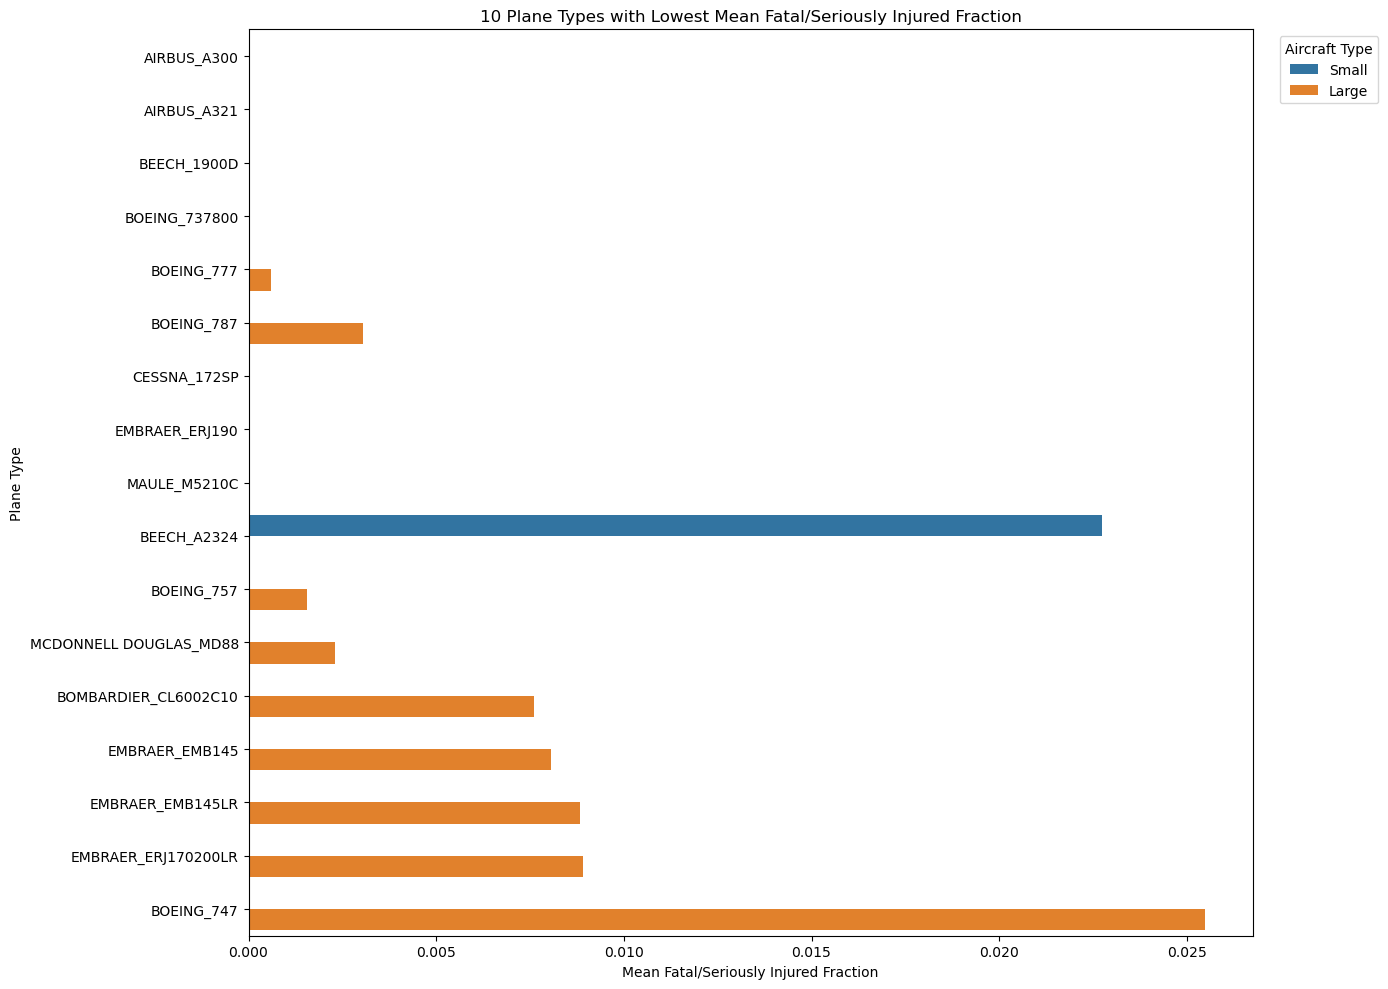

In [8]:

# Create Plane.Type

aviation_df['Plane.Type'] = (
    aviation_df['Make'].str.strip().str.upper() + '_' +
    aviation_df['Model'].str.strip().str.upper()
)


# Split into Small and Large aircraft


small_plane_type = aviation_df[
    aviation_df['Total.Estimated.People'] < 20
].copy()

large_plane_type = aviation_df[
    aviation_df['Total.Estimated.People'] >= 20
].copy()


# Require at least 10 observations per type

small_counts = small_plane_type['Plane.Type'].value_counts()
large_counts = large_plane_type['Plane.Type'].value_counts()

small_valid_types = small_counts[small_counts >= 10].index
large_valid_types = large_counts[large_counts >= 10].index

small_plane_type = small_plane_type[
    small_plane_type['Plane.Type'].isin(small_valid_types)
].copy()

large_plane_type = large_plane_type[
    large_plane_type['Plane.Type'].isin(large_valid_types)
].copy()


# Calculate mean injury fraction

small_type_risk = (
    small_plane_type
    .dropna(subset=['Injury.Percentage'])
    .groupby('Plane.Type')['Injury.Percentage']
    .mean()
    .reset_index()
)

large_type_risk = (
    large_plane_type
    .dropna(subset=['Injury.Percentage'])
    .groupby('Plane.Type')['Injury.Percentage']
    .mean()
    .reset_index()
)


# Get the 10 lowest for each aircraft size

small_top10 = small_type_risk.nsmallest(
    10, 'Injury.Percentage'
)

large_top10 = large_type_risk.nsmallest(
    10, 'Injury.Percentage'
)

# Add Group

small_top10['Group'] = 'Small'
large_top10['Group'] = 'Large'


# Combine ONLY the 10 lowest from each group

mean_risk = pd.concat([
    small_top10,
    large_top10
])


# Mean plot

plt.figure(figsize=(14, 10))

sns.barplot(
    data=mean_risk,
    x='Injury.Percentage',
    y='Plane.Type',
    hue='Group'
)

plt.xlabel('Mean Fatal/Seriously Injured Fraction')
plt.ylabel('Plane Type')
plt.title('10 Plane Types with Lowest Mean Fatal/Seriously Injured Fraction')

plt.legend(
    title='Aircraft Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()




# Keep ONLY the 10 selected plane types
selected_small = small_plane_type[
    small_plane_type['Plane.Type'].isin(small_top10['Plane.Type'])
].copy()

selected_large = large_plane_type[
    large_plane_type['Plane.Type'].isin(large_top10['Plane.Type'])
].copy()


distribution_df = pd.concat([
    selected_small.assign(Group='Small'),
    selected_large.assign(Group='Large')
]).dropna(
    subset=['Injury.Percentage']
)




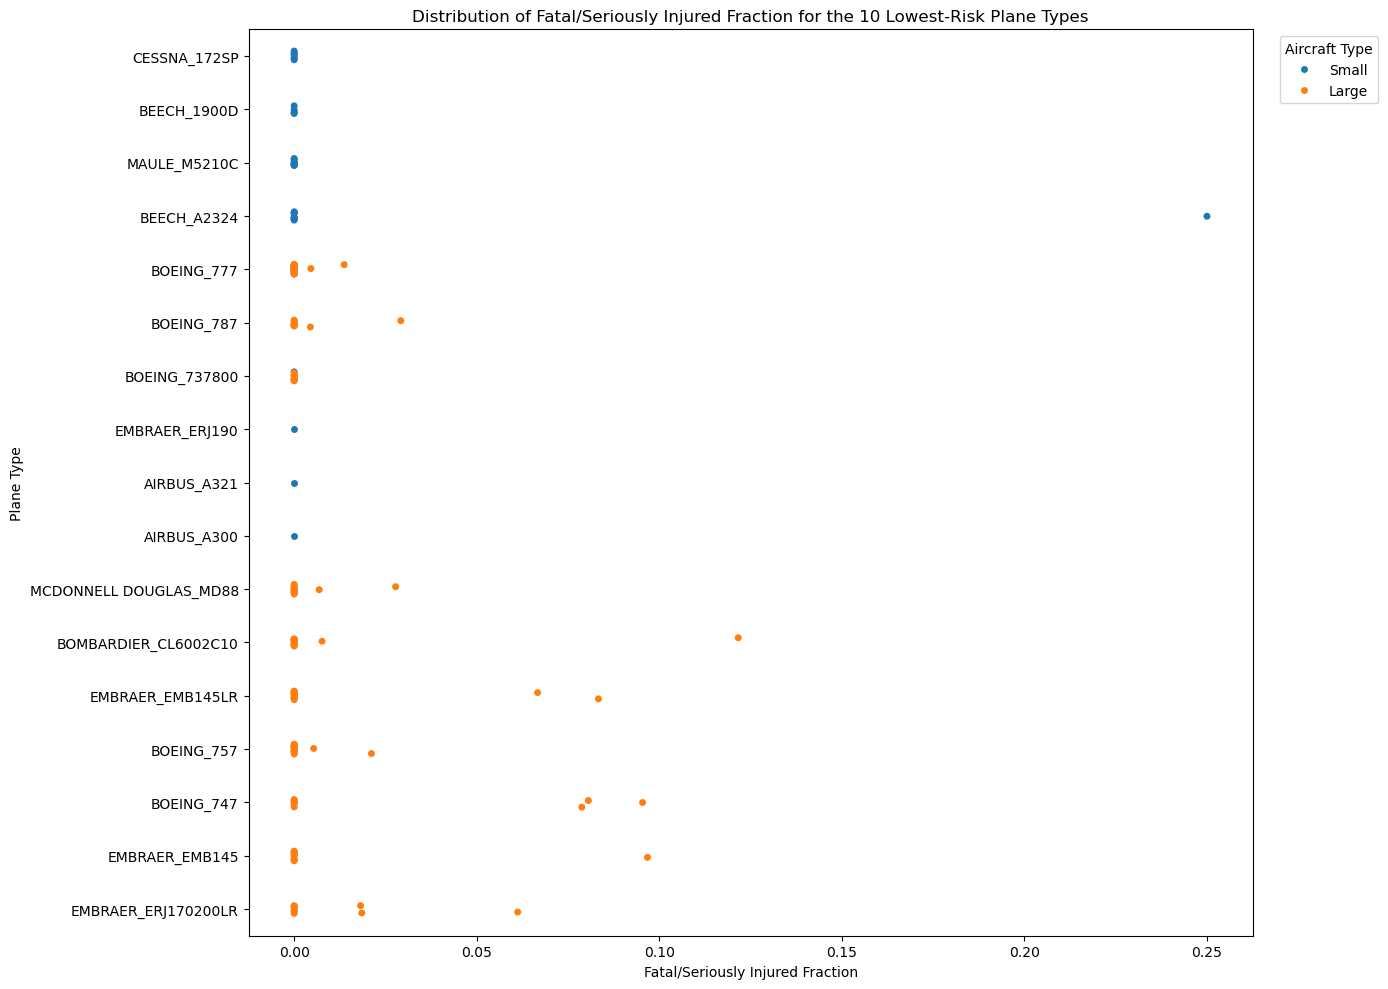

In [9]:
# Distribution plot

plt.figure(figsize=(14, 10))

ax = sns.stripplot(
    data=distribution_df,
    x='Injury.Percentage',
    y='Plane.Type',
    hue='Group',
    jitter=True
)

plt.xlabel('Fatal/Seriously Injured Fraction')
plt.ylabel('Plane Type')
plt.title(
    'Distribution of Fatal/Seriously Injured Fraction '
    'for the 10 Lowest-Risk Plane Types'
)

ax.legend(
    title='Aircraft Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Color plane-type names
for label in ax.get_yticklabels():
    plane = label.get_text()
    group = distribution_df.loc[
        distribution_df['Plane.Type'] == plane, 'Group'
    ].iloc[0]

   
        
plt.tight_layout()
plt.show()

For Small models - a recommendation for Beech1900D, or other planes that show a low fatal rate/fractions of injury. The Boeing 737800 shows the lowest fraction of injury for larger models, so this appears to be the recommended choice

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Completed above

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Comments added under the chart

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

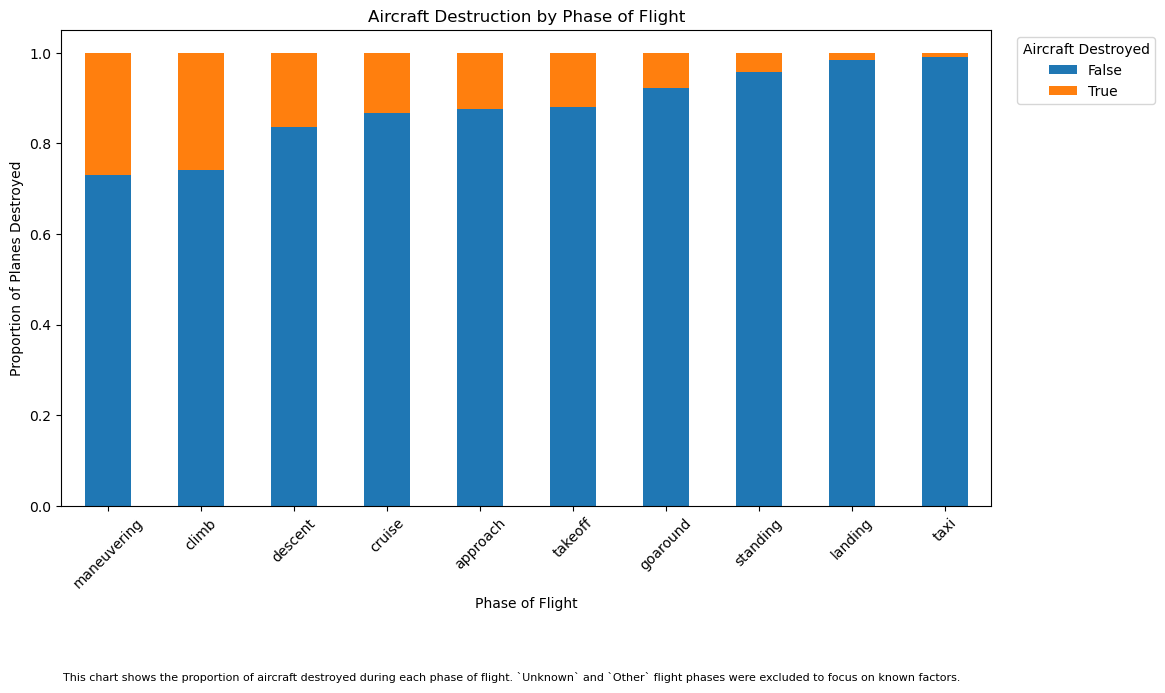

In [10]:
# Below I chose to explore aircraft destruction per phase of flight and weather.

# Remove Unknown and other factor to focus on known factors
aviation_df = aviation_df[
    aviation_df['Broad.phase.of.flight'] != 'unknown'
]
aviation_df = aviation_df[
    aviation_df['Broad.phase.of.flight'] != 'other'
]

# find the most destructive phases
destruction_phase = pd.crosstab(
    aviation_df['Broad.phase.of.flight'],
    aviation_df['Aircraft.destroyed'],
    normalize='index'
)

# Sort by proportion of aircraft destroyed for legibility
destruction_phase = destruction_phase.sort_values(
    by=True,
    ascending=False
)

# Plot chart
ax = destruction_phase.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.ylabel('Proportion of Planes Destroyed')
plt.xlabel('Phase of Flight')
plt.title('Aircraft Destruction by Phase of Flight')
plt.xticks(rotation=45)
plt.subplots_adjust(bottom=0.20)
plt.figtext(
    0.5,
    -0.05,
    'This chart shows the proportion of aircraft destroyed during each phase of flight. '
    '`Unknown` and `Other` flight phases were excluded to focus on known factors.',
    ha='center',
    fontsize=8
)
ax.legend(
    title='Aircraft Destroyed',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

Finding show that there are more crashes recorded during manuevering and climbing

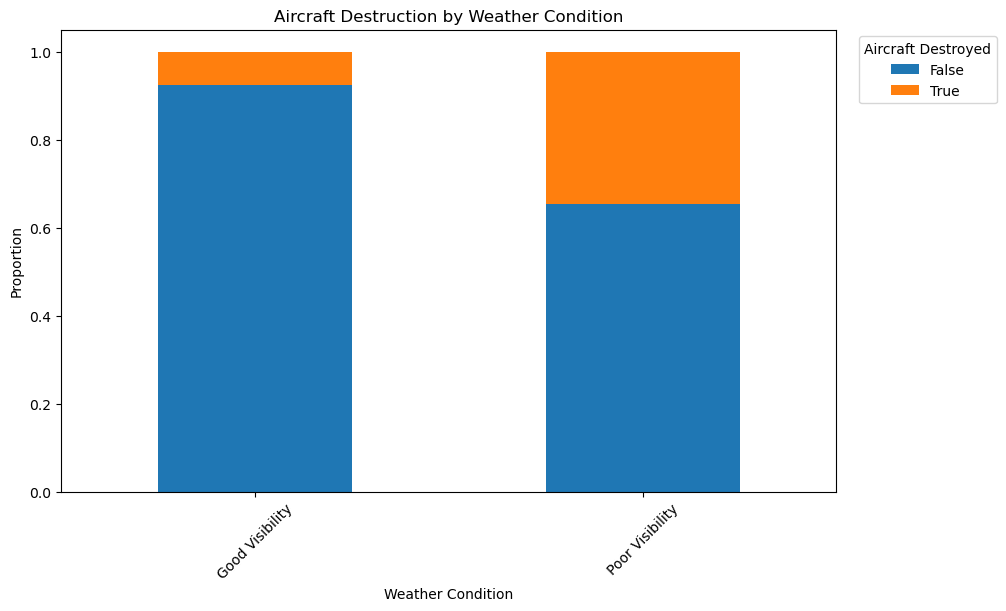

In [11]:
# Below I chose to explore aircraft destruction by weather condition.
# Remove Unknown factor to focus on known factors
aviation_df = aviation_df[
    aviation_df['Weather.Condition'] != 'unk'
]
aviation_df = aviation_df[
    aviation_df['Weather.Condition'] != 'other'
]

# update flight codes for readability. Updated on the definition found for these flight codes here: https://skybrary.aero/articles/instrument-meteorological-conditions-imc
make_mapping = {
    'imc': 'Poor Visibility',
    'vmc': 'Good Visibility',
}

for pattern, replacement in make_mapping.items():
    mask = aviation_df['Weather.Condition'].str.contains(
        pattern, case=False, na=False
    )
    aviation_df.loc[mask, 'Weather.Condition'] = replacement


# Capture weather conditions
aviation_df['Weather.Condition'].value_counts(dropna=False)
weather_destruction = pd.crosstab(
    aviation_df['Weather.Condition'],
    aviation_df['Aircraft.destroyed'],
    normalize='index'
)

# Plot weather condition factors
ax = weather_destruction.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Proportion')
plt.xlabel('Weather Condition')
plt.title('Aircraft Destruction by Weather Condition')
plt.xticks(rotation=45)

ax.legend(
    title='Aircraft Destroyed',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

Data shows that poor weather is a contributor in documented plane crashes

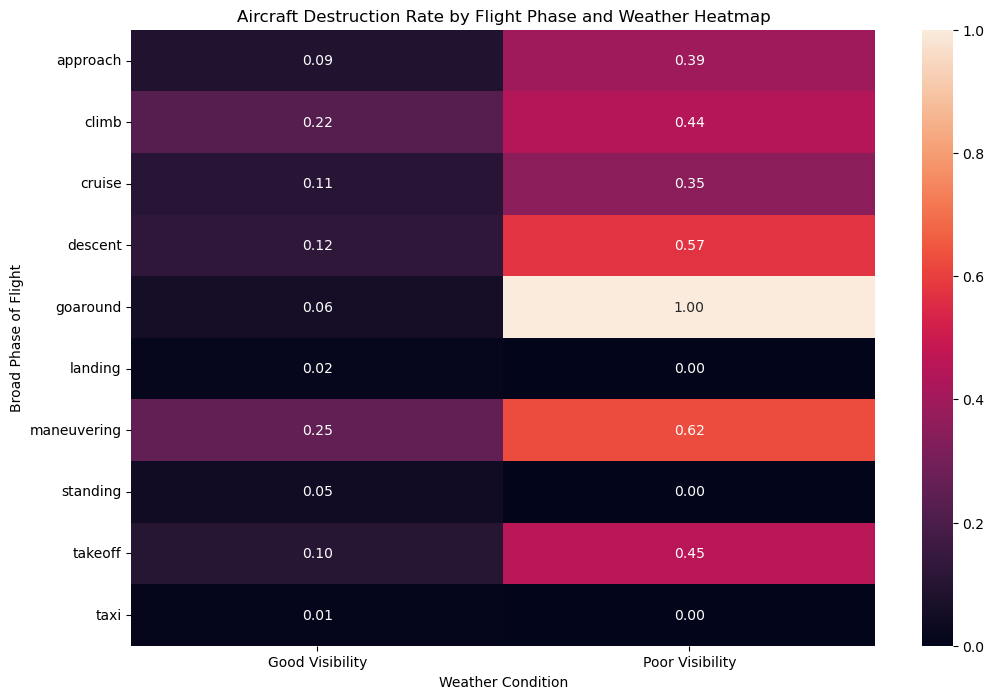

In [12]:

# Remove Unknown factor to focus on known factors
aviation_df = aviation_df[
    aviation_df['Weather.Condition'] != 'unk'
]
aviation_df = aviation_df[
    aviation_df['Weather.Condition'] != 'other'
]

# group by phase of flight and weather condition
phase_weather = (
    aviation_df
    .groupby(['Broad.phase.of.flight', 'Weather.Condition'])['Aircraft.destroyed']
    .mean()
    .reset_index(name='Destruction.Rate')
)

# create heatmap
heatmap_data = phase_weather.pivot(
    index='Broad.phase.of.flight',
    columns='Weather.Condition',
    values='Destruction.Rate'
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f'
)

plt.xlabel('Weather Condition')
plt.ylabel('Broad Phase of Flight')
plt.title('Aircraft Destruction Rate by Flight Phase and Weather Heatmap')
plt.show()

Bar to the right is a heatmap representing the severity of the weather. The most sever cases take place in poor visibility weather when a plane is going around , while the second most severe is in low visibility manuevering